# CTCF motif score and boundary optimization analysis

This notebook investigates whether the presence of CTCF motifs in a genomic window predicts the success of boundary optimization.

**Analysis overview:**
1. Load boundary optimization results for a single target strength (`boundary_neg0p5`).
2. Compute an aggregated positive CTCF motif score for each genomic window.
3. Compare motif scores between successfully and unsuccessfully optimized windows.
4. Load results from 10 independent optimization runs and assess whether motif score predicts how reproducibly a window can be optimized.

## 1. Imports

In [1]:
import os
import sys

import pandas as pd
from pathlib import Path
from pyfaidx import Fasta
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi_akita/"))

from utils.df_utils import load_optimization_results, load_indep_runs_results
from utils.fimo_utils import (
    read_meme_pwm_as_numpy,
    estimate_background_probs,
    compute_aggregated_positive_motif_scores,
)

## 2. Configuration

In [2]:
BASE_DIR = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries/results/")
INDEP_RUNS_DIR = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries/indep_runs_lambda_125.0")
PLOTS_DIR = Path("./../plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GENOME_FASTA = "/project2/fudenber_735/genomes/mm10/mm10.fa"
CTCF_MEME   = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

RESULT_DIRS = ["boundary_neg0p5"]
FOLDS = range(8)

# Offsets (relative to centered_start) defining the sequence window
# passed to the CTCF sliding-score calculation.
# The +/-9 bp padding accommodates the 19 bp CTCF PWM at window edges.
SEQ_START_OFFSET = 655360 - 9
SEQ_END_OFFSET   = 657408 + 9

## 3. Load optimization results

Each TSV contains one row per genomic window tested in a given fold, with predicted insulation scores before (`insul_score_orig`) and after (`insul_score_edited`) optimization.
An optimization is considered **successful** if the edited sequence has a lower insulation score than the original (i.e. a stronger predicted boundary).

In [3]:
df = load_optimization_results(RESULT_DIRS, BASE_DIR, FOLDS)

df["insul_score_diff"]     = df["insul_score_edited"] - df["insul_score_orig"]
df["optimization_success"] = df["insul_score_diff"] < 0

print(f"Loaded {len(df)} windows across {df['fold'].nunique()} folds")
print(f"Successful optimizations: {df['optimization_success'].sum()} / {len(df)}")

Loaded 355 windows across 8 folds
Successful optimizations: 323 / 355


## 4. Compute aggregated positive CTCF motif scores

For each genomic window we compute an **aggregated positive motif score**: the sum of all positive-valued sliding-window PWM scores across both strands.
This captures the total CTCF binding potential in the window — windows with more or stronger CTCF motifs will have higher scores.

Background nucleotide frequencies are estimated empirically from the set of optimized windows to avoid bias from uniform background assumptions.

In [4]:
genome   = Fasta(GENOME_FASTA)
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_MEME)
print(f"CTCF PWM shape: {pwm_CTCF.shape}  (L x 4, expected (19, 4))")

CTCF PWM shape: (19, 4)  (L x 4, expected (19, 4))


In [5]:
bg_probs = estimate_background_probs(df, genome)
print("Background nucleotide probabilities:", {k: round(v, 4) for k, v in bg_probs.items()})

Background nucleotide probabilities: {'A': 0.2908, 'C': 0.2088, 'G': 0.2089, 'T': 0.2915}


In [6]:
compute_aggregated_positive_motif_scores(
    df, genome, pwm_CTCF,
    seq_start_offset=SEQ_START_OFFSET,
    seq_end_offset=SEQ_END_OFFSET,
    bg=bg_probs,
)

print(f"Score range: {df['sum_positive_scores'].min():.2f} – {df['sum_positive_scores'].max():.2f}")

100%|██████████| 355/355 [00:47<00:00,  7.41it/s]

Score range: 0.00 – 101.12


## 5. Motif score distribution: successful vs. unsuccessful optimizations

We compare the distribution of CTCF motif scores between windows where optimization succeeded and where it failed.
A shift towards higher scores in successful windows would suggest that pre-existing CTCF binding potential facilitates boundary optimization.

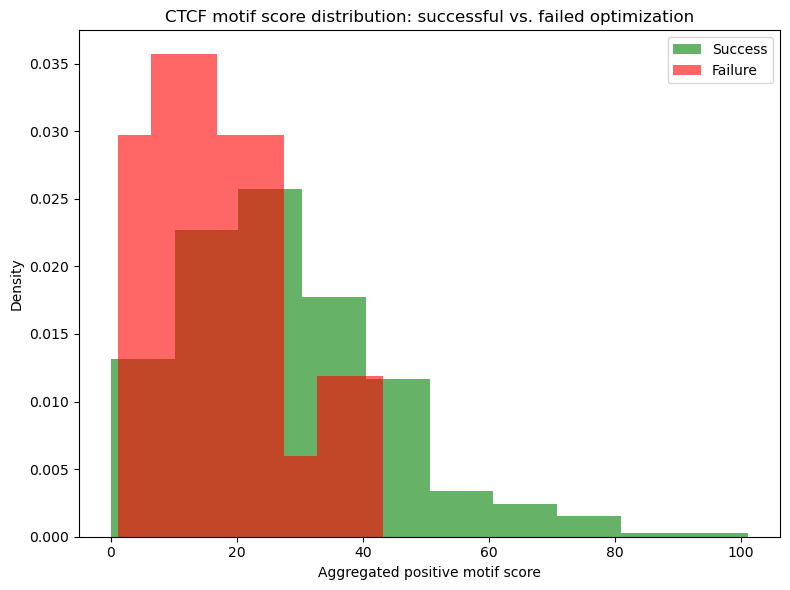

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    df[df["optimization_success"]]["sum_positive_scores"],
    bins=10, alpha=0.6, label="Success", color="green", density=True,
)
ax.hist(
    df[~df["optimization_success"]]["sum_positive_scores"],
    bins=8, alpha=0.6, label="Failure", color="red", density=True,
)

ax.set_xlabel("Aggregated positive motif score")
ax.set_ylabel("Density")
ax.set_title("CTCF motif score distribution: successful vs. failed optimization")
ax.legend()

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "success_failure_optimization_density.svg", format="svg")
plt.show()

## 6. Independent runs analysis

To assess optimization reproducibility, we load results from 10 independent runs (different random seeds) with a fixed lambda of 125.0, each covering folds 0–4.
For each genomic window we count how many of the 10 runs yielded a successful optimization — this **number of successful runs** serves as a measure of how reliably a given locus can be optimized.

We then ask whether the CTCF motif score (computed above) predicts this reproducibility.

In [8]:
df_runs = load_indep_runs_results(INDEP_RUNS_DIR)

df_runs["insul_score_diff"]     = df_runs["insul_score_edited"] - df_runs["insul_score_orig"]
df_runs["optimization_success"] = df_runs["insul_score_diff"] < 0

print(f"Loaded {len(df_runs)} rows ({df_runs['run'].nunique()} runs x {df_runs['fold'].nunique()} folds)")
print(f"Overall success rate: {df_runs['optimization_success'].mean():.1%}")

Loaded 1740 rows (10 runs x 4 folds)
Overall success rate: 89.4%


In [9]:
# Attach pre-computed CTCF motif scores from df (scores are window-level, not run-level)
df_runs = df_runs.merge(
    df[["chrom", "centered_start", "centered_end", "sum_positive_scores"]],
    on=["chrom", "centered_start", "centered_end"],
    how="left",
)
assert df_runs["sum_positive_scores"].isna().sum() == 0, "Some windows are missing motif scores!"

In [10]:
# Count successful runs per genomic window
successful_runs = (
    df_runs[df_runs["optimization_success"]]
    .groupby(["chrom", "centered_start", "centered_end"])
    .size()
    .reset_index(name="n_successful_runs")
)

# Right-merge to retain windows with zero successes
plot_df = successful_runs.merge(
    df_runs[["chrom", "centered_start", "centered_end", "sum_positive_scores"]].drop_duplicates(),
    on=["chrom", "centered_start", "centered_end"],
    how="right",
).fillna({"n_successful_runs": 0})
plot_df["n_successful_runs"] = plot_df["n_successful_runs"].astype(int)

print(f"Windows per success count:\n{plot_df['n_successful_runs'].value_counts().sort_index()}")

Windows per success count:
n_successful_runs
0       3
1       4
2       1
3       4
4       4
5       5
6       1
7       4
8       6
9       5
10    137
Name: count, dtype: int64


## 7. Motif score vs. number of successful runs

Each box summarises the distribution of CTCF motif scores for windows that were successfully optimized in exactly 0, 1, … 10 out of 10 runs.
A positive trend would indicate that windows with stronger CTCF motif content are more reliably optimized.

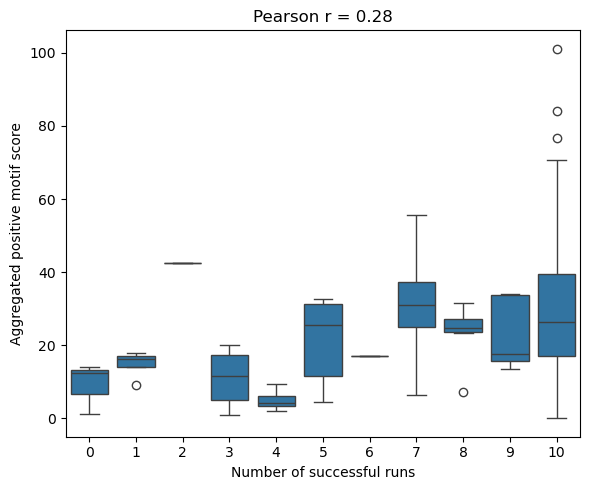

In [11]:
r = plot_df[["sum_positive_scores", "n_successful_runs"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=plot_df,
    x="n_successful_runs",
    y="sum_positive_scores",
    ax=ax,
)

ax.set_xlabel("Number of successful runs")
ax.set_ylabel("Aggregated positive motif score")
ax.set_title(f"Pearson r = {r:.2f}")

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "success_runs_sum_positive_scores.svg", format="svg")
plt.show()